In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [5]:
df = pd.read_csv("./data/titanic_clean.csv")

In [6]:
df.sample(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
164,0,3,male,1.0,4,1,39.6875,S
468,0,3,male,28.0,0,0,7.7250,Q
293,0,3,female,24.0,0,0,8.8500,S


In [7]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

# Fit and transform on training data
df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

In [ ]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
431,1,3,0,28.0,1,0,16.100,2
660,1,1,1,50.0,2,0,133.650,2
705,0,2,1,39.0,0,0,26.000,2
350,0,3,1,23.0,0,0,9.225,2
75,0,3,1,25.0,0,0,7.650,2


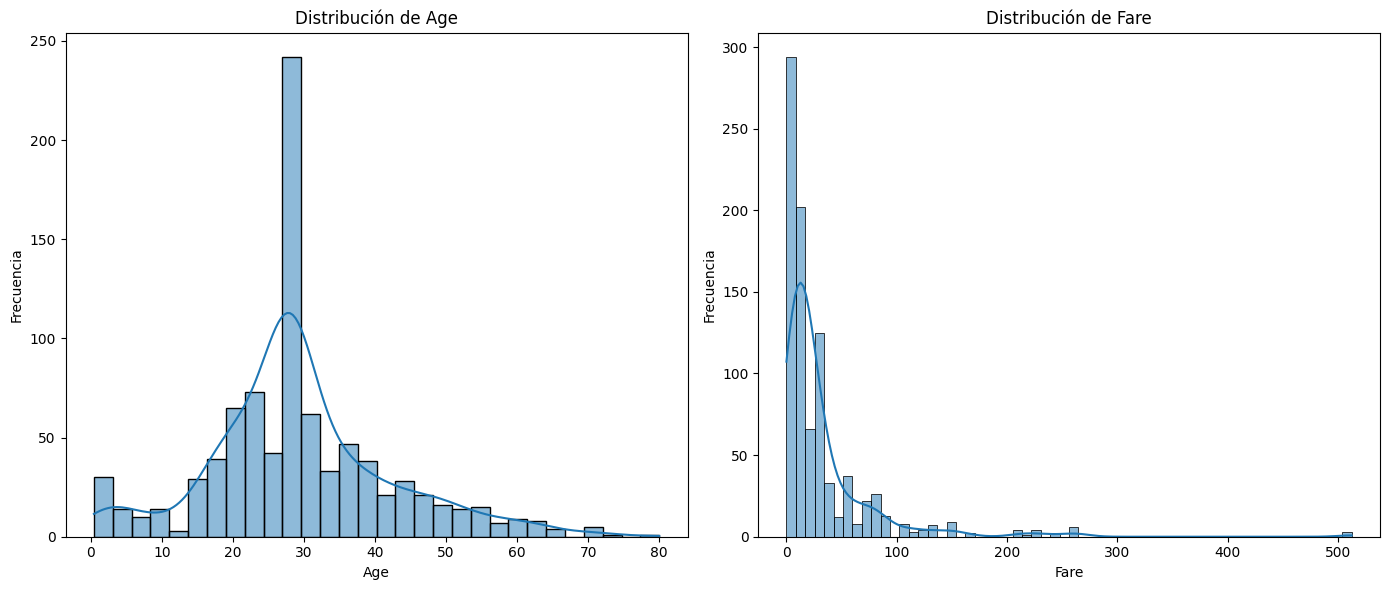

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

# Mostrar las gráficas
plt.tight_layout()
plt.show()

In [9]:
qun_tra_age = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

In [10]:
mms_pclass= MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

# Ejecutar transformaciones
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

In [14]:
df.sample(10)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
188,0,1.0,1.0,0.589745,0.125,0.166667,0.506769,0.5
393,1,0.0,0.0,0.440350,0.125,0.000000,0.659982,0.0
611,0,1.0,1.0,0.497826,0.000,0.000000,0.327073,1.0
370,1,0.0,1.0,0.456270,0.125,0.000000,0.597579,0.0
387,1,0.5,0.0,0.570590,0.000,0.000000,0.489594,1.0
531,0,1.0,1.0,0.497826,0.000,0.000000,0.357459,0.0
142,1,1.0,0.0,0.447788,0.125,0.000000,0.509435,1.0
127,1,1.0,1.0,0.447788,0.000,0.000000,0.338447,1.0
332,0,0.0,1.0,0.579431,0.000,0.166667,0.686781,1.0
858,1,1.0,0.0,0.447788,0.000,0.500000,0.517241,0.0


In [13]:
df.to_csv('./data/titanic_procesado.csv', index=False)